## This is how Bagging/RandomForest works Internally By Using Combined Sampling

### Importing Libraries

In [66]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

#### Generating a Synthetic Classification Dataset

In [67]:
X , y = make_classification(n_features=5, n_informative=5, n_redundant=0, n_clusters_per_class=1)

In [68]:
df = pd.DataFrame(X , columns=['col1', 'col2' , 'col3', 'col4', 'col5'])
df['target'] = y

In [69]:
df

,col1,col2,col3,col4,col5,target
0,-1.043527,1.736044,-1.563063,1.511204,1.075880,1
1,1.764728,1.072201,-1.055128,0.477256,-1.226945,1
2,-1.094326,1.309508,-2.029414,0.969344,1.182247,1
3,-0.146261,0.306992,-1.700266,0.782827,1.670599,1
4,-1.157426,1.018445,-1.356520,-0.998871,0.764072,0
...,...,...,...,...,...,...
95,1.405990,-0.736682,-3.506498,-0.980825,0.537269,0
96,1.444099,0.165086,-0.611356,1.115722,-1.679361,1
97,-1.181397,-0.158858,-1.581007,-1.871975,0.964328,0
98,-1.734716,-0.481774,-0.022733,1.911752,1.683318,1


In [70]:
df.shape

(100, 6)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col1    100 non-null    float64
 1   col2    100 non-null    float64
 2   col3    100 non-null    float64
 3   col4    100 non-null    float64
 4   col5    100 non-null    float64
 5   target  100 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 4.8 KB


In [72]:
df.head()

,col1,col2,col3,col4,col5,target
0,-1.043527,1.736044,-1.563063,1.511204,1.075880,1
1,1.764728,1.072201,-1.055128,0.477256,-1.226945,1
2,-1.094326,1.309508,-2.029414,0.969344,1.182247,1
3,-0.146261,0.306992,-1.700266,0.782827,1.670599,1
4,-1.157426,1.018445,-1.356520,-0.998871,0.764072,0


### Function for Combination Sampling
##### Both Rows and Columns

In [73]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)


# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df


# function for combined sampling
def combine_samples(df, row_percent, feature_percent):
    new_df = sample_rows(df, row_percent)
    return sample_features(new_df, feature_percent)

## Using Combine Sampling

#### `RandomForest` is collection of decision tree 
Now we will Create 3 new datasets using Combine Sampling With Replacement

In [74]:
df1 = combine_samples(df, 0.5, 0.5)
df1

C:\Users\hb292\AppData\Local\Temp\ipykernel_11988\361865943.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col3,col4,target
89,-2.424968,0.480695,0
63,0.667984,0.630305,0
15,-1.121713,0.648290,1
42,-0.611386,1.062405,0
24,-0.833781,-0.688775,0
51,-0.881441,-1.330174,0
62,-0.189955,-0.567071,0
55,-0.146622,0.610232,1
93,0.517492,1.664274,0
2,-2.029414,0.969344,1


In [75]:
df2 = combine_samples(df, 0.5, 0.5)
df2

C:\Users\hb292\AppData\Local\Temp\ipykernel_11988\361865943.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col4,col1,target
18,-0.433714,2.547319,0
12,1.460427,0.433355,1
53,-0.938669,0.506516,0
30,1.259836,-1.368123,1
55,0.610232,-3.129682,1
1,0.477256,1.764728,1
81,0.873602,-0.458515,0
54,2.055287,-1.816985,1
15,0.648290,0.509497,1
75,-1.075512,-2.277588,0


In [76]:
df3 = combine_samples(df, 0.5, 0.5)
df3

C:\Users\hb292\AppData\Local\Temp\ipykernel_11988\361865943.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col4,col5,target
9,-0.814457,1.335680,0
52,-0.832828,-0.252571,0
8,1.252607,1.804659,1
83,-2.630951,2.186908,0
29,1.379723,-1.093421,1
2,0.969344,1.182247,1
2,0.969344,1.182247,1
80,-2.551273,0.908048,0
86,1.463063,-0.127583,1
27,-2.343344,2.304600,0


In [77]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col4', 'target'], dtype='object')
Index(['col4', 'col1', 'target'], dtype='object')
Index(['col4', 'col5', 'target'], dtype='object')


## Calling DecisionTreeClassifier and making object for my 3 datasets

In [78]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [79]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Plotting 3 Decision Tree by Combined Sampling

In [82]:
from sklearn.tree import plot_tree

[Text(0.5666666666666667, 0.9444444444444444, 'x[1] <= 0.639\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.26666666666666666, 0.8333333333333334, 'x[0] <= -0.656\ngini = 0.363\nsamples = 21\nvalue = [16, 5]'),
 Text(0.41666666666666663, 0.8888888888888888, 'True  '),
 Text(0.13333333333333333, 0.7222222222222222, 'x[0] <= -3.081\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.06666666666666667, 0.6111111111111112, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2, 0.6111111111111112, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.4, 0.7222222222222222, 'x[0] <= -0.334\ngini = 0.494\nsamples = 9\nvalue = [5, 4]'),
 Text(0.3333333333333333, 0.6111111111111112, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4666666666666667, 0.6111111111111112, 'x[1] <= 0.62\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.4, 0.5, 'x[0] <= 0.148\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.3333333333333333, 0.3888888888888889, 'x[1] <= 0.609\ngini = 0.375\ns

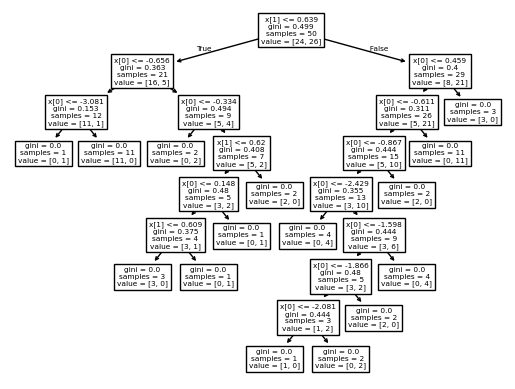

In [83]:
plot_tree(clf1)

[Text(0.5, 0.9285714285714286, 'x[0] <= -0.181\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.4230769230769231, 0.7857142857142857, 'gini = 0.0\nsamples = 18\nvalue = [18, 0]'),
 Text(0.46153846153846156, 0.8571428571428572, 'True  '),
 Text(0.5769230769230769, 0.7857142857142857, 'x[0] <= 1.085\ngini = 0.305\nsamples = 32\nvalue = [6, 26]'),
 Text(0.5384615384615384, 0.8571428571428572, '  False'),
 Text(0.3076923076923077, 0.6428571428571429, 'x[1] <= -0.508\ngini = 0.486\nsamples = 12\nvalue = [5, 7]'),
 Text(0.15384615384615385, 0.5, 'x[0] <= 1.016\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.07692307692307693, 0.35714285714285715, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.23076923076923078, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.46153846153846156, 0.5, 'x[1] <= 1.489\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.38461538461538464, 0.35714285714285715, 'x[0] <= 0.564\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),


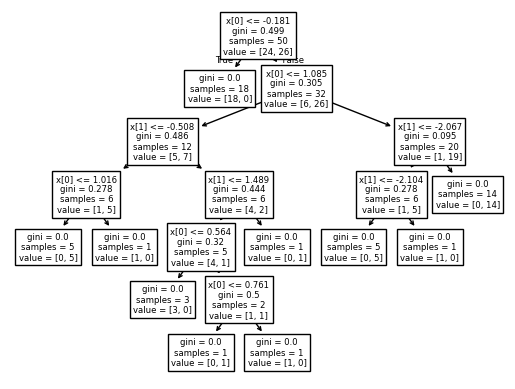

In [84]:
plot_tree(clf2)

[Text(0.4, 0.9, 'x[0] <= -0.188\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.2, 0.7, 'gini = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.30000000000000004, 0.8, 'True  '),
 Text(0.6, 0.7, 'x[1] <= -0.432\ngini = 0.238\nsamples = 29\nvalue = [4, 25]'),
 Text(0.5, 0.8, '  False'),
 Text(0.4, 0.5, 'x[0] <= 1.221\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.2, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6, 0.3, 'x[0] <= 1.522\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 24\nvalue = [0, 24]')]

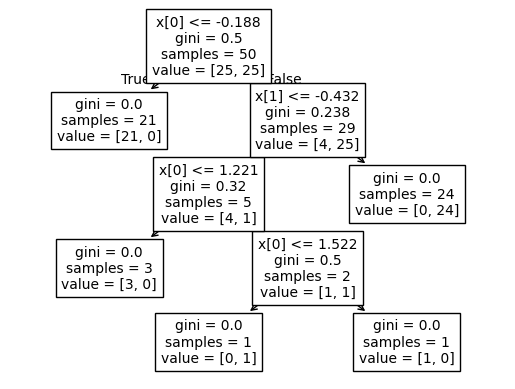

In [85]:
plot_tree(clf3)

### We will predict a random datapoint manually To see how each decision tree is Predicting

In [86]:
clf1.predict(np.array([-2.343344,	2.304600]).reshape(1,2))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [87]:
clf2.predict(np.array([-2.343344,	2.304600]).reshape(1,2))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [88]:
clf3.predict(np.array([-2.343344,	2.304600]).reshape(1,2))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

### Query point answer should be `0`